# Finalisation

Une fois toutes les données téléchargées et restructurées, on peut obtenir les données finales
et vérifier rapidement leur conformité sur des cartes.

Voir le [README](./README.md) pour plus de détails.

In [3]:
import pandas as pd
from tqdm import tqdm

In [4]:
FILE_AGRESTE_PATH = './'

# attention, en cas d'ajout, 
DATAFRAMES = {
    'agreste_ift_2017' : {
        'path' : FILE_AGRESTE_PATH+'ift/gcpe/ift_culture_ancienne_region_gcpe_2017.csv',
        'campagne' : 2017
    }, 
    'agreste_ift_2021' : {
        'path' : FILE_AGRESTE_PATH+'ift/gcpe/ift_culture_ancienne_region_gcpe_2021.csv',
        'campagne' : 2021
    }, 
    'agreste_ift_hts_2017' : {
        'path' : FILE_AGRESTE_PATH+'ift/gcpe/ift_hts_culture_ancienne_region_gcpe_2017.csv',
        'campagne' : 2017
    }, 
    'agreste_ift_hts_2021' : {
        'path' : FILE_AGRESTE_PATH+'ift/gcpe/ift_hts_culture_ancienne_region_gcpe_2021.csv',
        'campagne' : 2021
    }, 
    'agreste_surface' : {
        'path' : FILE_AGRESTE_PATH+'restructure/surface_espece_ancienne_region_restructure.csv',        
    }
}
df = {}

In [5]:
STUDIED_CAMPAGNES = [2017, 2021]

In [6]:
# chargement des données
for key, dataframe in DATAFRAMES.items():
    df[key] = pd.read_csv(dataframe['path'])

In [ ]:
agreste_ift_reference_region = {}
for STUDIED_CAMPAGNE in STUDIED_CAMPAGNES :
    # on reforme le dataset : avoir les culutres en colonne est pratique pour visualiser
    # mais on préfère avoir une ligne par enregistrement pour pouvoir fusionner
    df['agreste_ift_'+str(STUDIED_CAMPAGNE)] = df['agreste_ift_'+str(STUDIED_CAMPAGNE)].melt(
        id_vars = 'nom_ancienne_region'
    )
    df['agreste_ift_'+str(STUDIED_CAMPAGNE)]['campagne'] = STUDIED_CAMPAGNE

    # on ajoute aux surfaces les ift 
    left = df['agreste_surface']
    right = df['agreste_ift_'+str(STUDIED_CAMPAGNE)].rename(columns={
        'value' : 'ift'
    })
    df['agreste_surface_complet_'+str(STUDIED_CAMPAGNE)] = pd.merge(
        left,
        right, 
        left_on=['Espece_SSP_corrige', 'Campagne', 'Nom_Ancienne_Region'], 
        right_on= ['variable', 'campagne', 'nom_ancienne_region'],
        how='inner'
    )

    # 1 on ajoute les informations sur les IFT traitement de semence
    # l'objectif et de les retrancher
    left = df['agreste_surface_complet_'+str(STUDIED_CAMPAGNE)]
    right = df['agreste_ift_hts_'+str(STUDIED_CAMPAGNE)].set_index('Indicateur').T
    df['agreste_surface_complet_'+str(STUDIED_CAMPAGNE)] = pd.merge(left, right, left_on = 'variable', right_index=True, how='left')


    df['agreste_surface_complet_'+str(STUDIED_CAMPAGNE)]

    # 2  Colonne ift  (on conserve l'original pour la comparaison)
    df['agreste_surface_complet_'+str(STUDIED_CAMPAGNE)]['ift_num'] = pd.to_numeric(
        df['agreste_surface_complet_'+str(STUDIED_CAMPAGNE)]['ift'], errors='coerce'
    )
    # 3  Colonne ift_traitement_semence (on convertit en numérique)
    df['agreste_surface_complet_'+str(STUDIED_CAMPAGNE)]['ift_trt_num'] = \
        df['agreste_surface_complet_'+str(STUDIED_CAMPAGNE)]['ift_traitement_semence'].str.replace(',', '.')

    df['agreste_surface_complet_'+str(STUDIED_CAMPAGNE)]['ift_trt_num'] = df['agreste_surface_complet_'+str(STUDIED_CAMPAGNE)]['ift_trt_num'].astype('float')
    df['agreste_surface_complet_'+str(STUDIED_CAMPAGNE)]['ift_mod'] = df['agreste_surface_complet_'+str(STUDIED_CAMPAGNE)]['ift_num']  # on commence par la valeur d’origine

    # On ne soustrait que lorsqu’il y a bien un traitement
    mask = df['agreste_surface_complet_'+str(STUDIED_CAMPAGNE)]['ift_trt_num'].notna()
    df['agreste_surface_complet_'+str(STUDIED_CAMPAGNE)].loc[mask, 'ift_mod'] = \
        df['agreste_surface_complet_'+str(STUDIED_CAMPAGNE)].loc[mask, 'ift_num'] - \
        df['agreste_surface_complet_'+str(STUDIED_CAMPAGNE)].loc[mask, 'ift_trt_num']

    df['agreste_surface_complet_'+str(STUDIED_CAMPAGNE)]['contribution_ift'] = round(
        df['agreste_surface_complet_'+str(STUDIED_CAMPAGNE)]['Part_surface_espece_region'] * \
        df['agreste_surface_complet_'+str(STUDIED_CAMPAGNE)]['ift_mod'] \
        / 100, 
        2
    )

    # Attention, on se rend compte que, pour beaucoup de culture, on a pas d'IFT disponible dans Agreste.
    # on recompile donc une surface de région correspondant à la somme des surfaces avec un ift non null.
    df['agreste_surface_ift_region_'+str(STUDIED_CAMPAGNE)] = df['agreste_surface_complet_'+str(STUDIED_CAMPAGNE)].loc[
        ~df['agreste_surface_complet_'+str(STUDIED_CAMPAGNE)]['ift_mod'].isna()
    ].groupby(['Campagne', 'Nom_Ancienne_Region']).agg({
        'Surface_Espece_Region' : 'sum'
    }).reset_index().rename(columns={
        'Surface_Espece_Region' : 'Surface_Region_Avec_IFT'
    })

    # on rajoute l'information au dataframe principal
    left = df['agreste_surface_complet_'+str(STUDIED_CAMPAGNE)]
    right = df['agreste_surface_ift_region_'+str(STUDIED_CAMPAGNE)][['Nom_Ancienne_Region', 'Surface_Region_Avec_IFT']]
    df['agreste_surface_complet_'+str(STUDIED_CAMPAGNE)+'_extanded'] = pd.merge(
        left, 
        right, 
        on = 'Nom_Ancienne_Region', 
        how='left'
    )

    # on compile une nouvelle portion
    df['agreste_surface_complet_'+str(STUDIED_CAMPAGNE)+'_extanded']['Part_surface_espece_region_avec_ift'] = \
        df['agreste_surface_complet_'+str(STUDIED_CAMPAGNE)+'_extanded']['Surface_Espece_Region'] / \
        df['agreste_surface_complet_'+str(STUDIED_CAMPAGNE)+'_extanded']['Surface_Region_Avec_IFT']

    # on calcule une contribution_ift_corrigée
    df['agreste_surface_complet_'+str(STUDIED_CAMPAGNE)+'_extanded']['contribution_ift_corrigee'] = round(
        df['agreste_surface_complet_'+str(STUDIED_CAMPAGNE)+'_extanded']['Part_surface_espece_region_avec_ift'] * \
        df['agreste_surface_complet_'+str(STUDIED_CAMPAGNE)+'_extanded']['ift_mod'], 
        2
    )


    df['agreste_ift_reference_region_'+str(STUDIED_CAMPAGNE)] = df['agreste_surface_complet_'+str(STUDIED_CAMPAGNE)+'_extanded'].groupby('Nom_Ancienne_Region').agg({
        'contribution_ift_corrigee' : 'sum'
    })

    df['agreste_ift_reference_region_'+str(STUDIED_CAMPAGNE)]['contribution_ift_corrigee'] = \
        round(df['agreste_ift_reference_region_'+str(STUDIED_CAMPAGNE)]['contribution_ift_corrigee'], 2)

    agreste_ift_reference_region[STUDIED_CAMPAGNE] = df['agreste_ift_reference_region_'+str(STUDIED_CAMPAGNE)]

    df['agreste_ift_reference_region_'+str(STUDIED_CAMPAGNE)].reset_index().rename(columns={
        'Nom_Ancienne_Region' : 'nom_ancienne_region', 
        'contribution_ift_corrigee' : 'ift_moyen_gcpe_can'
    }).set_index('nom_ancienne_region').to_csv('final/agreste_ift_gcpe_reference_region_'+str(STUDIED_CAMPAGNE)+'.csv')

In [10]:
df['agreste_ift_reference_region_'+str(STUDIED_CAMPAGNE)]

,contribution_ift_corrigee
Nom_Ancienne_Region,
Alsace,2.14
Aquitaine,1.87
Auvergne,2.35
Basse-Normandie,3.41
Bourgogne,3.80
Bretagne,2.82
Centre-Val de Loire,4.32
Champagne-Ardenne,4.52
Franche-Comté,3.92


### Affichage (vérification)

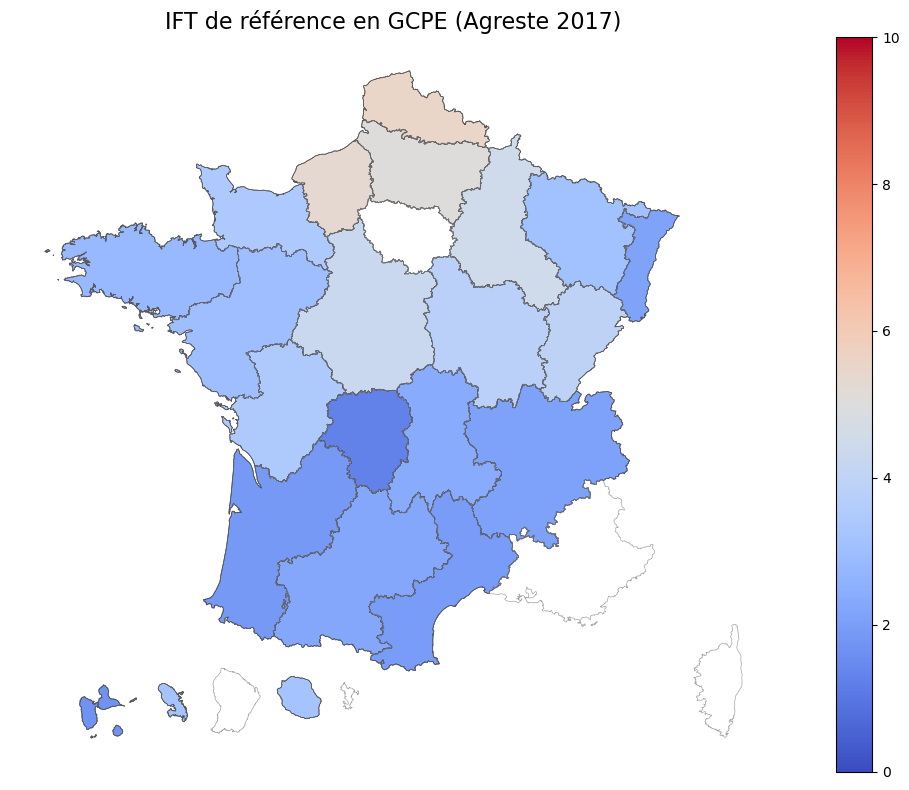

In [9]:
# -*- coding: utf-8 -*-
"""
Code généré grace à ARGO, 11 septembre 2026
"""

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

STUDIED_CAMPAGNE = 2017

# ------------------------------------------------------------------
# 1. Charger le DataFrame d’IFT
# ------------------------------------------------------------------
# Exemple de chargement depuis un CSV
# df_ift = pd.read_csv('ift_par_region.csv')  # <-- à adapter

# Pour rester générique, on crée un DataFrame fictif (conseil : supprime cette partie quand tu ais ton fichier)
df_ift = agreste_ift_reference_region[STUDIED_CAMPAGNE]

# ------------------------------------------------------------------
# 2. Charger le fichier géométrique des anciennes régions
# ------------------------------------------------------------------
# Remplace le chemin par celui de ton fichier shapefile / geojson
# Par exemple : shapefile = 'ancienne_regions_france.shp'
shapefile = '../geospatial_data/geoVec_oldreg.json'
gdf_regions = gpd.read_file(shapefile)

# gdf_regions.loc[
#     gdf_regions['Region_old'] == 'Centre-Val de Loire', 'Region_old'
# ] = 'Centre'

# ------------------------------------------------------------------
# 4. Fusionner les deux jeux
# ------------------------------------------------------------------
gdf_merged = gdf_regions.merge(df_ift, left_on='Region_old', right_on='Nom_Ancienne_Region', how='left')

# Si certaines régions ne trouvent pas d’IFT, elles devront
# être inspectées ou précisées (ex : valider les noms, ajouter des
# valeurs NA, etc.)

# ------------------------------------------------------------------
# 5. Visualiser
# ------------------------------------------------------------------
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
# On masque les frontières extérieures pour une meilleure lisibilité
gdf_merged.boundary.plot(ax=ax, linewidth=0.5, color='grey', alpha=0.7)

# Petite option supplémentaire : rendre les polygones transparents
#gdf_merged.plot(column='ift',
#                cmap='viridis',  # ou 'plasma', 'coolwarm', ...
#                linewidth=0.5,
#                edgecolor='black',
#                legend=True,
#                ax=ax,
#                alpha=0.8)    # pour voir les frontières

# Ici on décide d’un rendu complet (sans alpha) :
norm = TwoSlopeNorm(vcenter=5, vmin=0, vmax=10)

gdf_merged.plot(column='contribution_ift_corrigee',
                cmap='coolwarm',
                norm=norm,
                linewidth=0.5,
                edgecolor='black',
                legend=True,
                ax=ax)

ax.set_title('IFT de référence en GCPE (Agreste '+str(STUDIED_CAMPAGNE)+')', fontsize=16)
ax.axis('off')

fichier = 'ift_ancienne_regions_'+str(STUDIED_CAMPAGNE)+'.png'
plt.savefig(fichier,
            dpi=300,                # résolution (300→qualité print, 72→web)
            bbox_inches='tight',    # enlève les marges blanches
            transparent=False)      # false pour un fond blanc


plt.tight_layout()
plt.show()
